# Swarm Data Fusion toolbox demo notebook

**Swarm Data Fusion is a Python tool designed to combine Swarm satellite data with a wide range of ionosphere-thermosphere observations. The goal of SwarmDF is to maximize contextual information around the Swarm satellites for studying local electrodynamics in the high-latitude ionosphere.**


This notebook serves as documentation for the SwarmDF Python module. It guides the reader step by step through a typical SwarmDF run.

Alternatively, users may run swarmDF_GUI.py from a terminal to access a graphical user interface. The GUI is designed to be user-friendly and does not require prior familiarity with the package. It provides the outputs needed for further analysis.

For users who wish to go beyond the GUI, the same analysis can be reproduced by following the steps presented in this notebook.

## Imports

In [1]:
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# from swarmdf.core.swarm_orbit_and_grid import swarm_trajectory
# from swarmdf.core.data_collect import DataManager
# from swarmdf.core.lompe_analysis import run_lompe, lompe_output
# from swarmdf.core.conductance import compute_conductances
# from swarmdf.core.lompeOSSE_analysis import run_lompeOSSE, lompeOSSE_output
from swarmdf import *


## Input

### Main input

Start by choosing a Swarm satellite and defining the time interval for the study.  
This is the only input required before SwarmDF can run. All additional parameters have default values.

In [2]:
sat_id = 'A'
start = datetime(2014, 12, 15, 1, 12, 0)
end   = datetime(2014, 12, 15, 1, 14, 0)

### Datasets


Choose datasets among SuperDARN, SuperMAG, Iridium/Ampere, Swarm electric field and Swarm magnetic field. By default, all datasets are selected. 

In [3]:
datasets2download = ['superdarn', 'supermag', 'iridium_ampere', 'swarm_mag', "swarm_efield"]

### Grid

Define the extent, spatial resolution, and temporal spacing of the successive 2D regions surrounding the selected Swarm satellite along its trajectory.

In [ ]:
L, W = 1000,1000
Lres, Wres = 70, 70

grid_params = L, W, Lres, Wres #TODO make this a dict 
# todo add wshift to grid_params?

time_step = 60 # [s]

### Conductance

! Coductances are a major input for Lompe. 
Define the model of your choice. 

In [5]:
conductance_method = 'Zang & Paxton model'

kp_value = 4
f107_value = 100
background_value = 2 

conductance_params = {"kp": kp_value, "f107": f107_value, "background": background_value}

## Data fusion 

!! 
using sample input datasets
collect swarm data + collect additional data around swarm satellite track within grid + show trajectory and data distribution

The script data_collect.py runs in the background, it checks if the datafiles requested by the user already exist in their data folder, and downloads the files if not. 

SwarmDF will gather Swarm orbit data together with the additional datasets and perform Lompe analyses on those grids, with a default temporal spacing of 30 s between successive grids/analyses.

In [6]:
######################
# Collect data
######################

from importlib.resources import files
data_path = str(files("swarmdf") / "data" / "sample_datasets") + "/"
print(data_path)

# Fetch and load data
datahandler = DataManager(start, data_path, datasets2download)
datasets = datahandler.datasets

/Users/margot/Docs/Academia/Research/Python/SwarmDF/src/swarmdf/data/sample_datasets/
Fetching data...
Loading data...
Loaded swarm data from disk.
Loaded swarm_mag data from disk.
⚠️  swarm_efield: file loaded but dataset is EMPTY (0 rows)
Loaded superdarn data from disk.
Loaded supermag data from disk.
Loaded iridium_ampere data from disk.


In [7]:
datasets['swarm']

,MLT,Latitude,Radius,F,Spacecraft,Longitude,F_MCO_SHA_2D,F_IGRF,QDLat,QDLon,...,B_NEC_MCO_SHA_2D_C,B_NEC_N,B_NEC_E,B_NEC_C,B_NEC_IGRF_N,B_NEC_IGRF_E,B_NEC_IGRF_C,B_n,B_e,B_u
Timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-15 00:00:00,15.307294,26.147953,6835831.60,33871.6407,A,-122.220974,33876.015262,33876.851443,31.439939,-54.797306,...,26210.032453,21073.8774,4028.7373,26209.2949,21080.515519,4021.810144,26212.172216,-6.638119,6.927156,2.877316
2014-12-15 00:00:00,15.412182,25.665464,6835916.06,0.0000,C,-120.791327,33823.121815,33824.395313,31.201914,-53.223995,...,26083.283130,21158.7969,3949.0443,26083.8070,21167.900932,3940.940712,26085.986175,-9.104032,8.103588,2.179175
2014-12-15 00:00:00,16.613516,30.891504,6886573.76,37106.1835,B,-103.723153,37100.400343,37097.497717,39.474663,-35.203972,...,31847.165917,18895.9945,2182.7065,31859.6978,18905.381545,2172.726737,31844.782053,-9.387045,9.979763,-14.915747
2014-12-15 00:00:10,15.318048,25.508602,6835946.98,33580.8184,A,-122.226256,33585.592973,33586.648697,30.793816,-54.677898,...,25719.650196,21214.9360,4015.5305,25718.7185,21221.804735,4009.575393,25721.999916,-6.868735,5.955107,3.281416
2014-12-15 00:00:10,15.422656,25.026116,6836031.50,0.0000,C,-120.796904,33531.123298,33532.628879,30.554012,-53.108776,...,25588.463612,21299.9464,3936.5906,25588.6184,21309.056932,3929.823743,25591.361385,-9.110532,6.766857,2.742985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-15 23:59:40,21.897301,-82.173324,6845219.09,40989.9651,A,38.132717,41008.384121,41007.640363,-73.628510,44.267799,...,-38740.529886,6908.1504,-11642.4217,-38689.4255,6823.819537,-11587.175842,-38740.152440,84.330863,-55.245858,-50.726940
2014-12-15 23:59:40,17.270971,-30.702507,6895117.90,24952.1853,B,-102.240585,24972.079219,24971.249389,-21.379345,-25.127129,...,-15423.207416,18899.3340,5222.8793,-15431.9431,18934.783926,5216.370847,-15421.631849,-35.449926,6.508453,10.311251
2014-12-15 23:59:50,17.283340,-31.333395,6895166.96,25114.2651,B,-102.248663,25133.529613,25132.879877,-21.967407,-24.983459,...,-15792.967468,18788.1475,5295.8607,-15801.3388,18823.232097,5289.445667,-15791.432768,-35.084597,6.415033,9.906032


In [8]:
smag = datasets['supermag']
smag.lat.max()

79.300003

Plot the local grid along the Swarm trajectory as well as the selected data.
A gif is created in the user's folder. 

The swarm_orbit_and_grid.py script ... 

In [9]:
# Animation speed
gif_speed= 550 # [ms]
# TODO make these parameters default values in swarm_traj and lompe and lompeosse

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


hemisphere: north
Generating SwarmA trajectory animation for each time step...
Empty DataFrame
Columns: [Radius, Ehz, Ehx, Evy, QDLat, QDLon, Evz, OrbitNumber, Latitude, Ehy, Longitude, Spacecraft, MLT, Evx, B_NEC_MCO_SHA_2D_N, B_NEC_MCO_SHA_2D_E, B_NEC_MCO_SHA_2D_C, B_NEC_IGRF_N, B_NEC_IGRF_E, B_NEC_IGRF_C]
Index: []


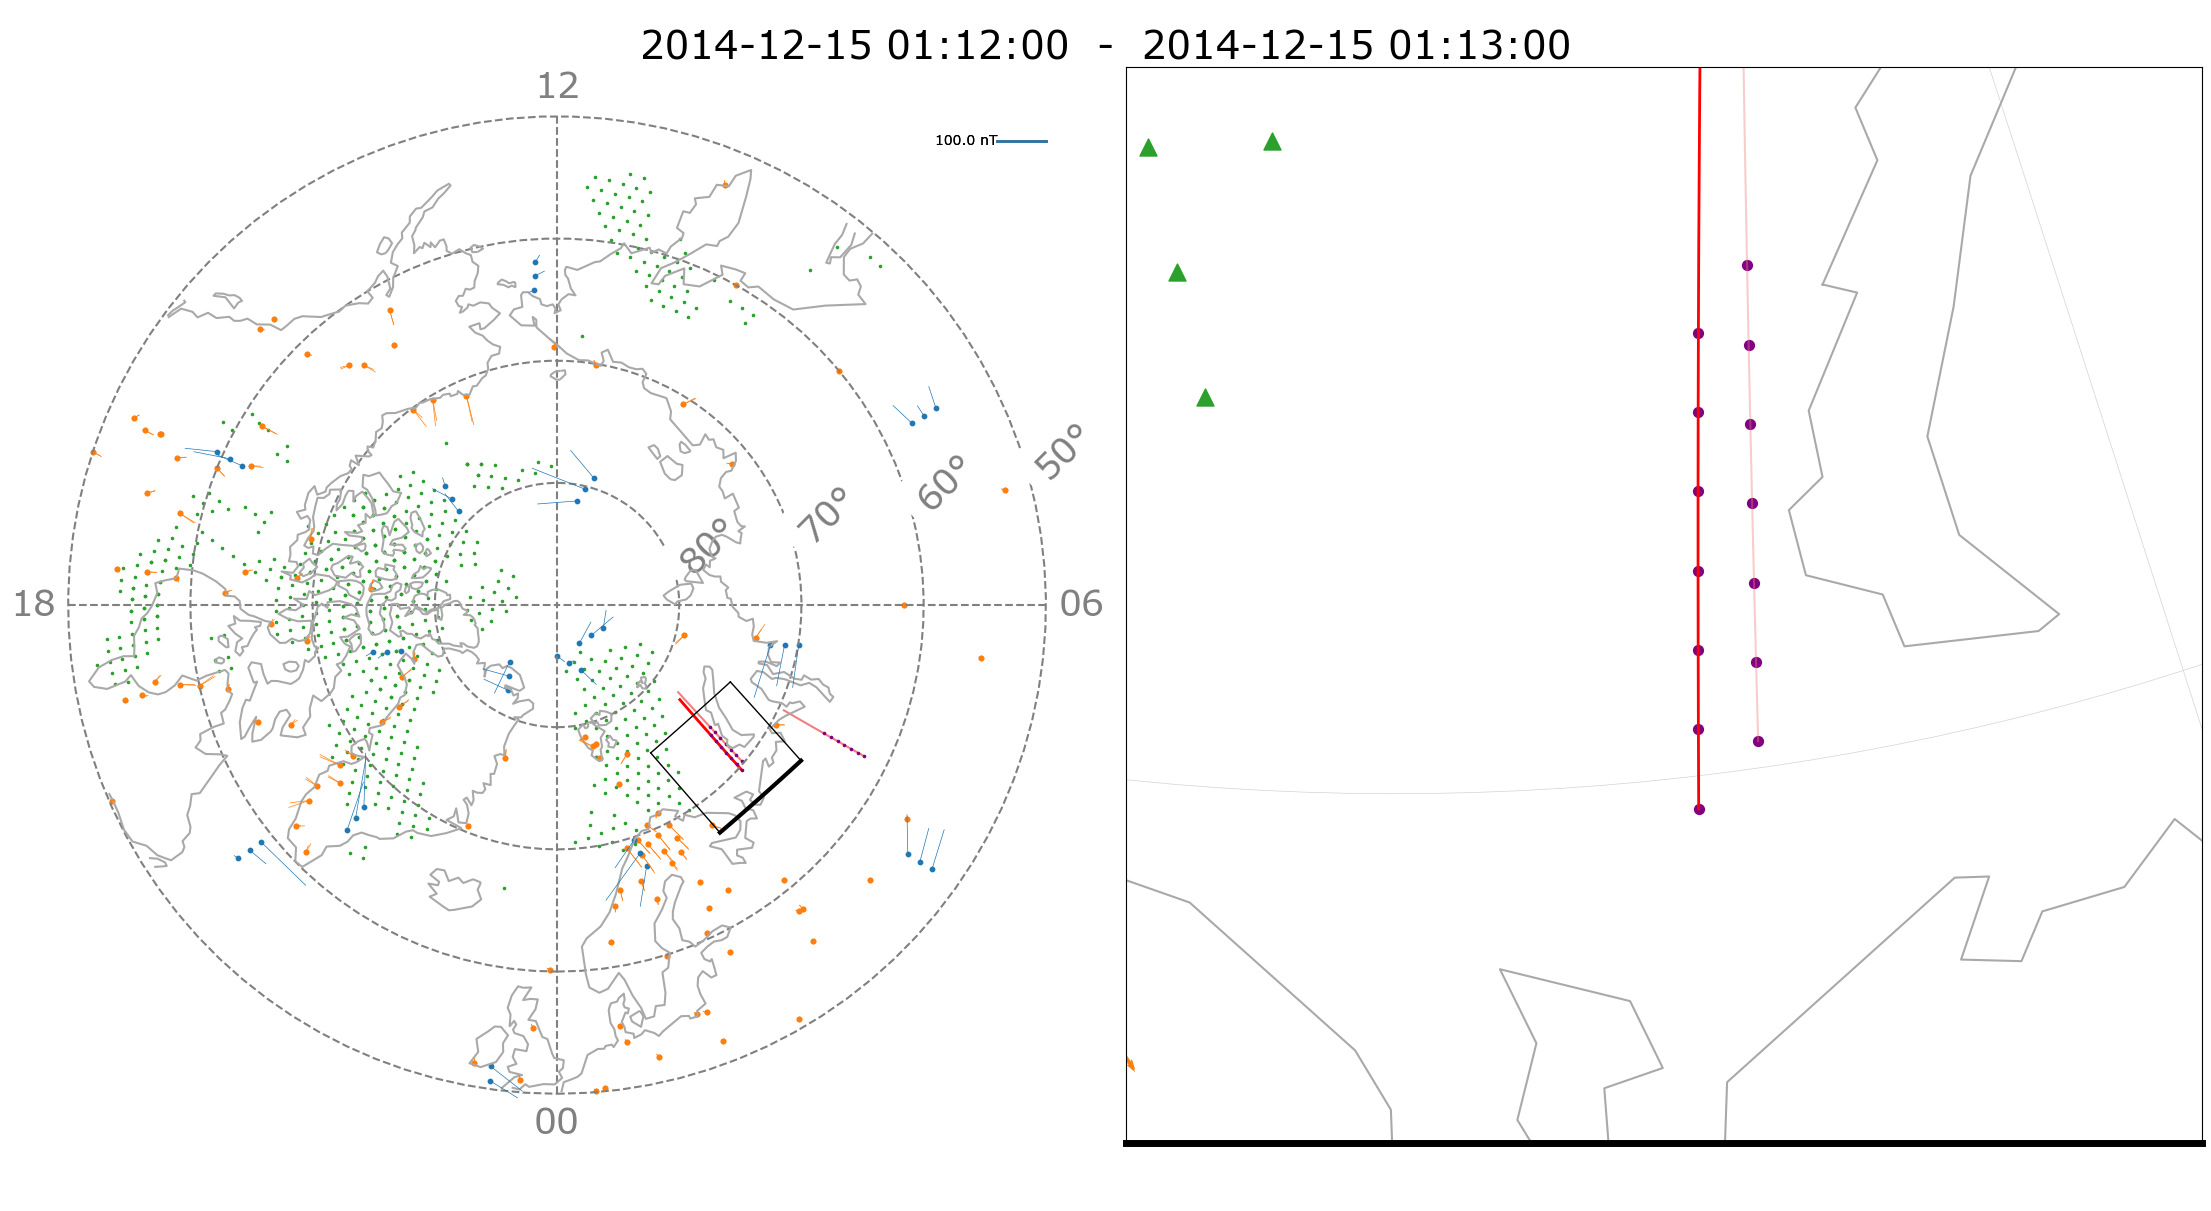

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Empty DataFrame
Columns: [Radius, Ehz, Ehx, Evy, QDLat, QDLon, Evz, OrbitNumber, Latitude, Ehy, Longitude, Spacecraft, MLT, Evx, B_NEC_MCO_SHA_2D_N, B_NEC_MCO_SHA_2D_E, B_NEC_MCO_SHA_2D_C, B_NEC_IGRF_N, B_NEC_IGRF_E, B_NEC_IGRF_C]
Index: []


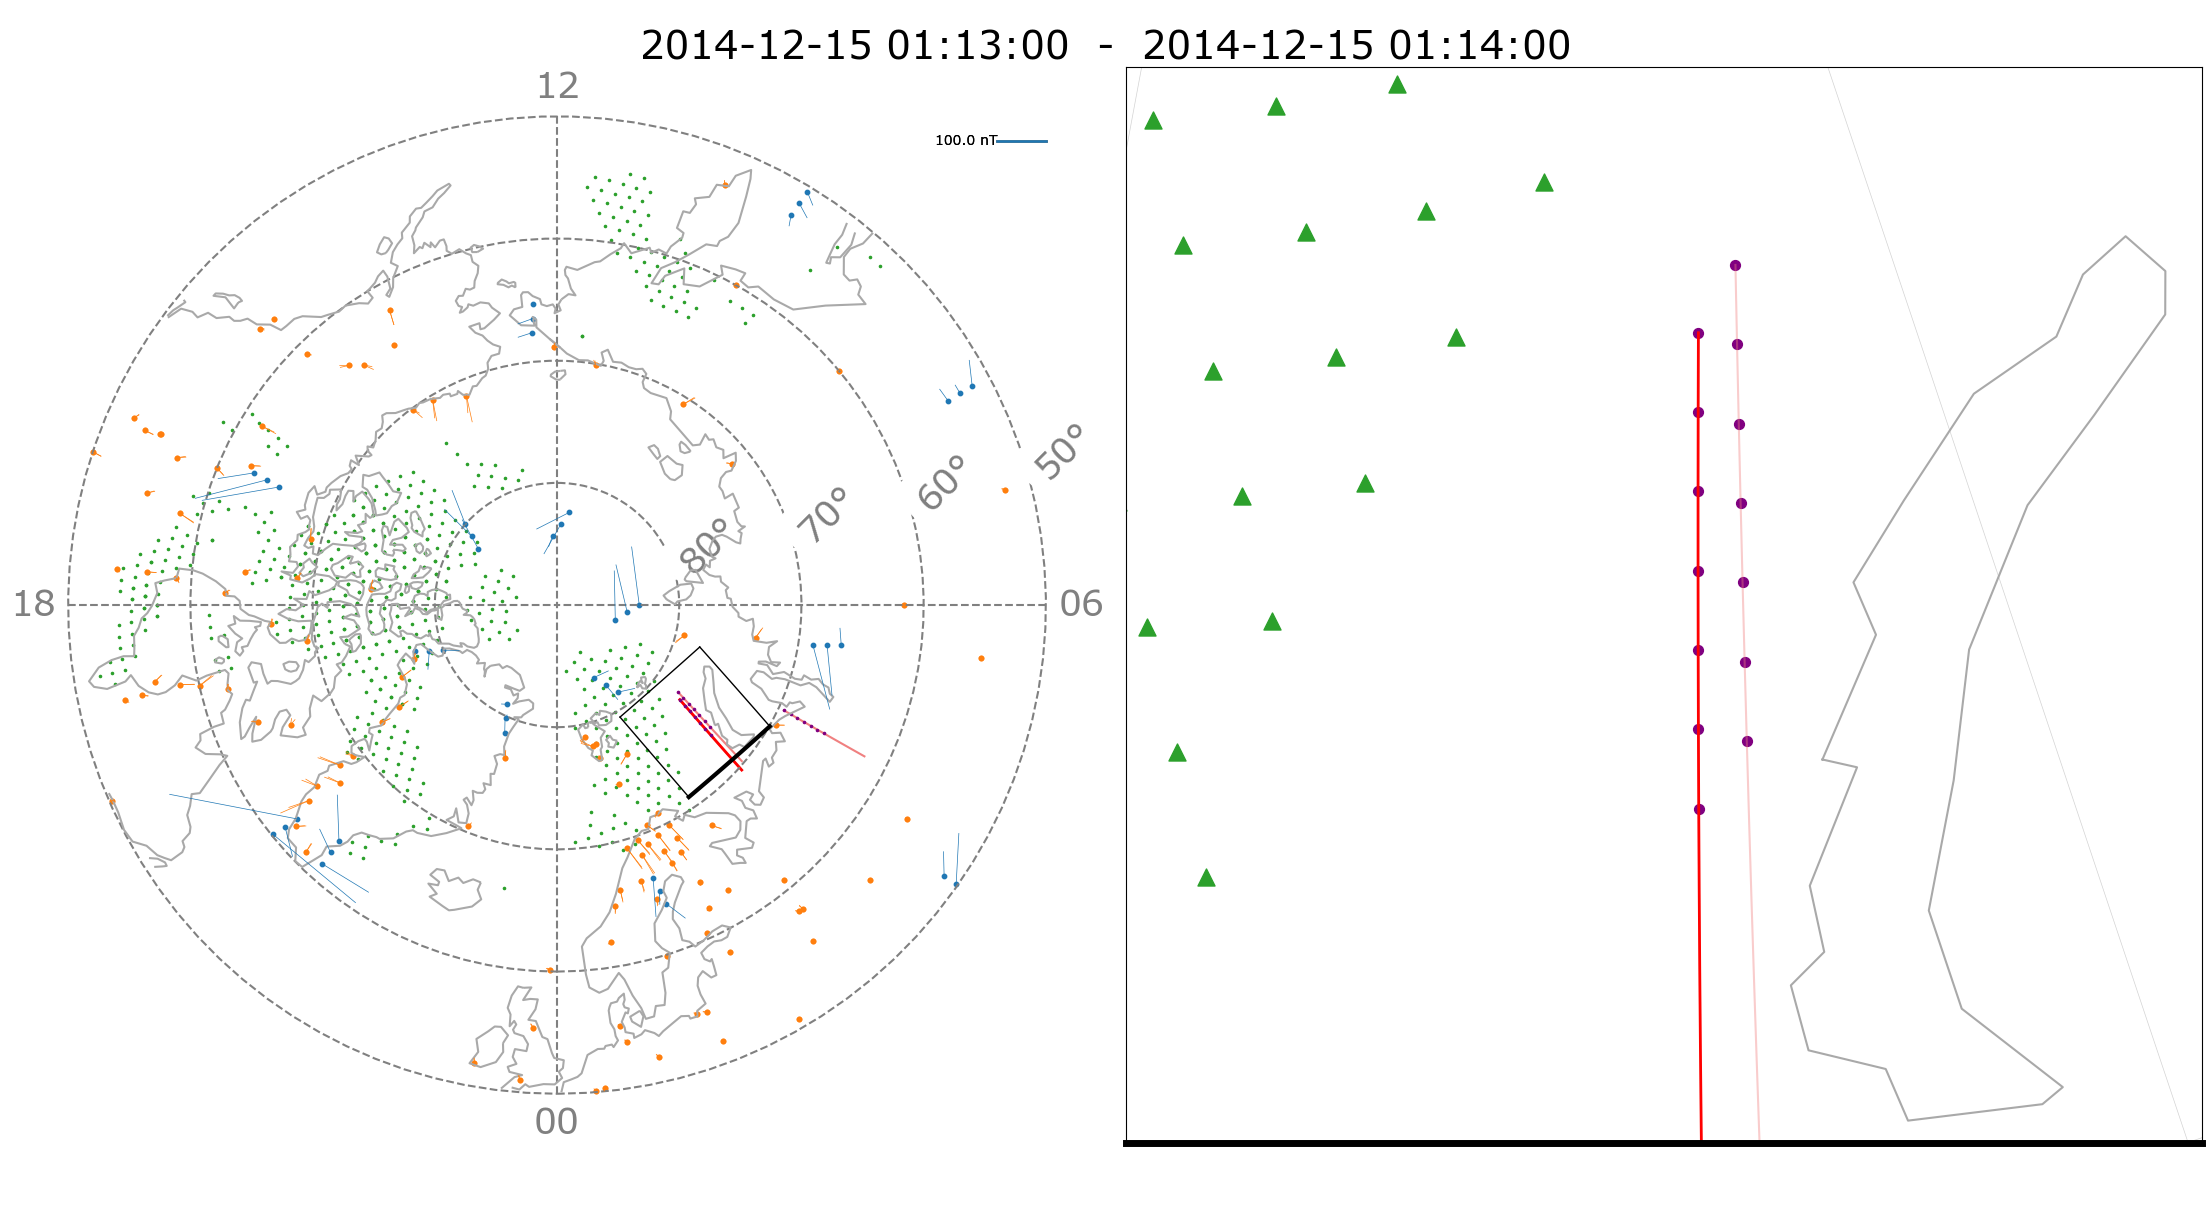

Figures with Swarm trajectory, grid, and data distribution for each time step saved in: /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/tmp/
GIF saved in outputs directory: /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/swarmA_and_data.gif


In [ ]:
center_times, grids, data_frames = swarm_trajectory(sat_id, start, end, time_step, grid_params, datasets, gif_speed, show_data=True)

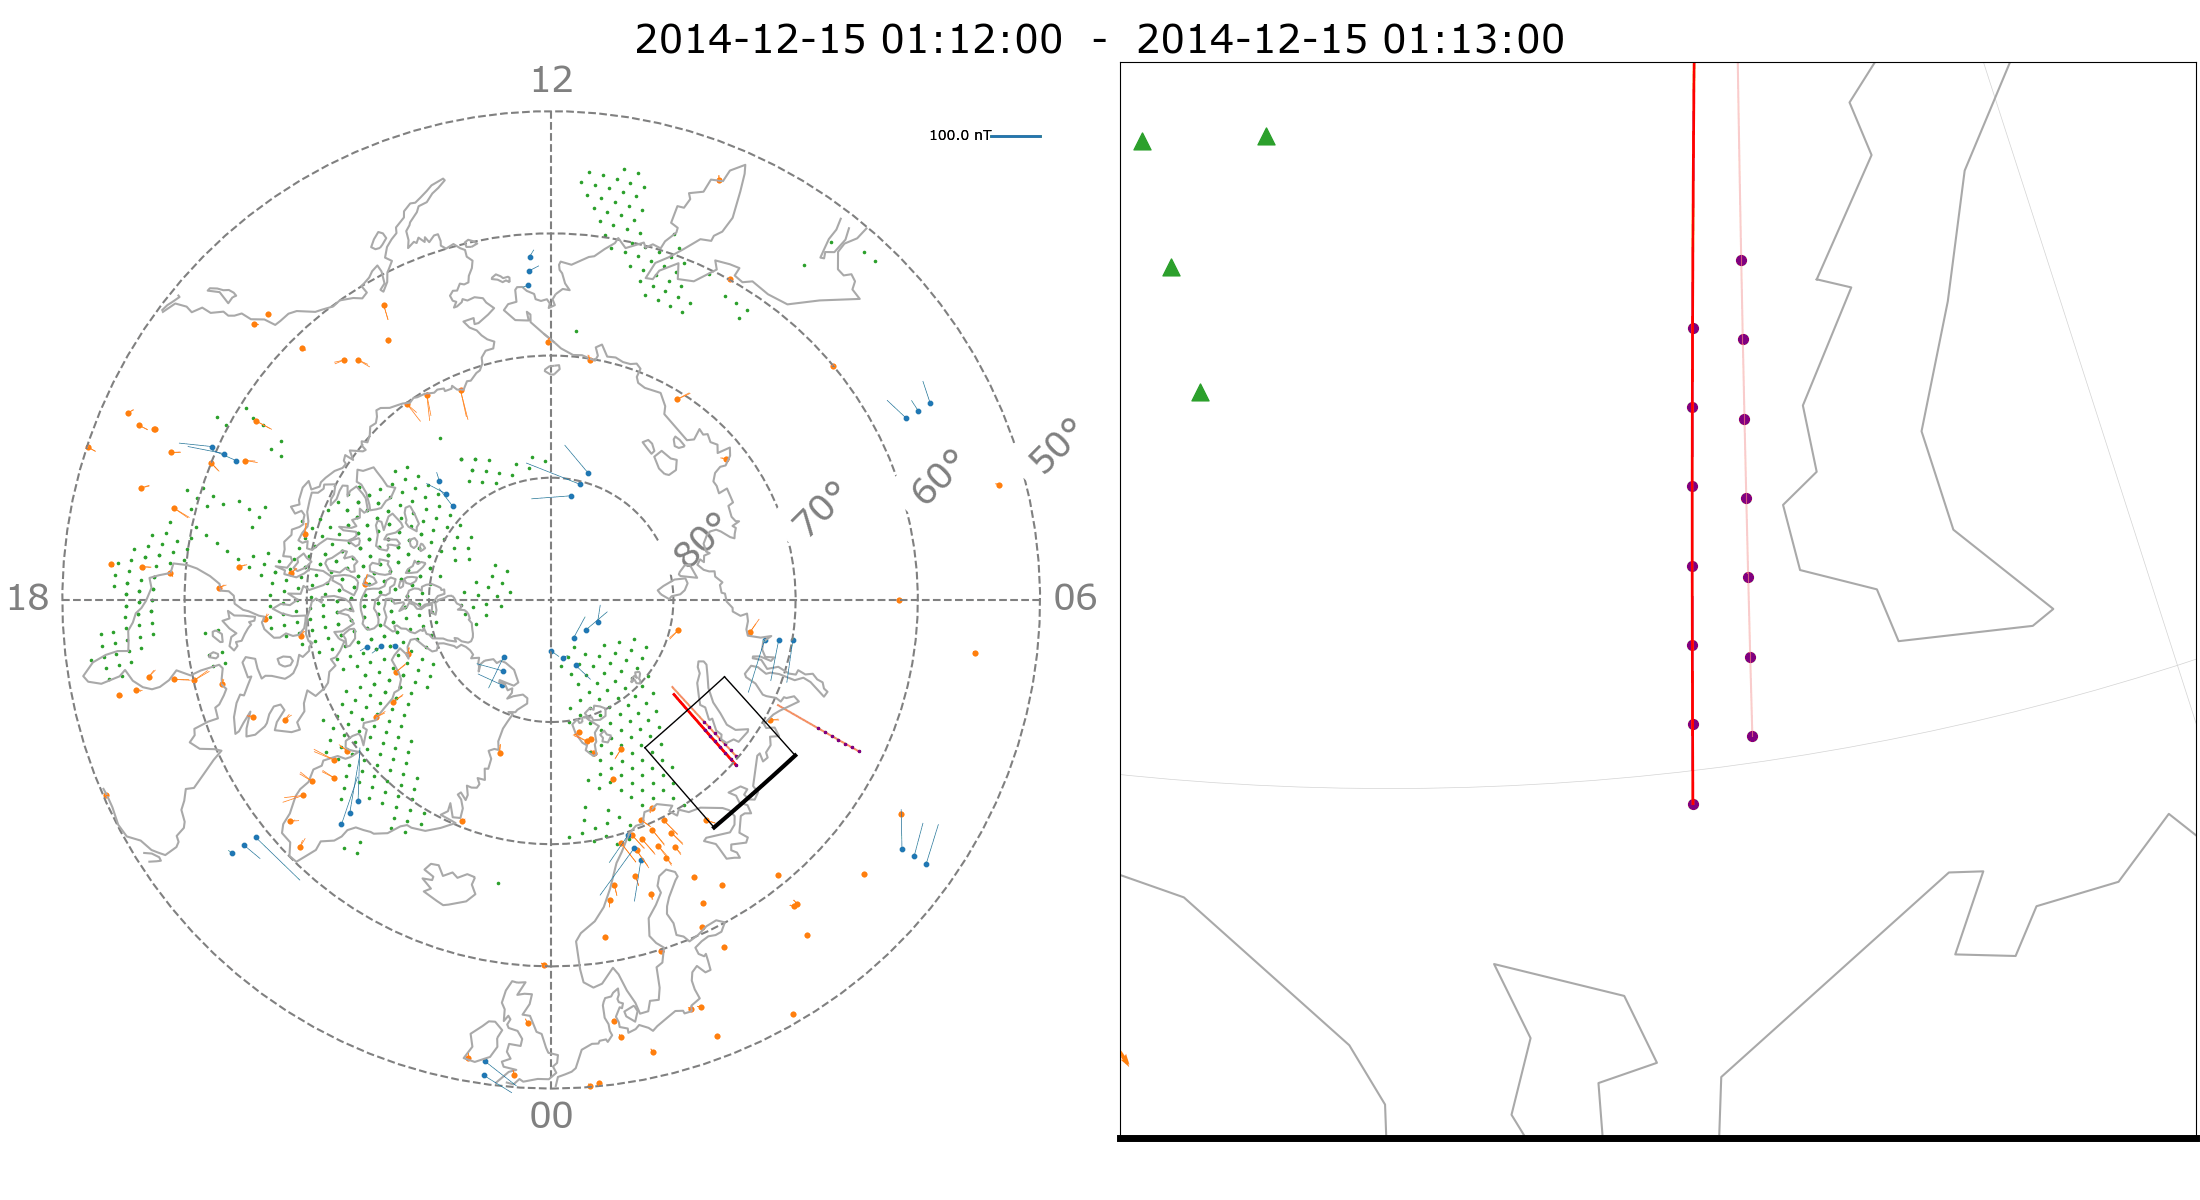

In [11]:
data_frames[0].save(
    "trajectory.gif",
    save_all=True,
    append_images=data_frames[1:],
    duration=750,
    loop=0
)

from IPython.display import Image, display

display(Image(filename='trajectory.gif')) #TODO compare with the gif saved in outputs

## Run Lompe analysis

Define conductance

In [12]:
SHs, SPs = compute_conductances(conductance_method, start, end, time_step, grids, conductance_params)

Conductance method: Zang & Paxton model


Create Lompe Emodel, run inversion and plot reconstructed electrodynamics

Running Lompe analysis (l1=1.00, l2=1.00)
! need to fix Swarm elec function in prepare_data
space_mag_fac: Measurement uncertainty effectively changed from 3e-08 to 4.2426406871192844e-08
! need to fix Swarm elec function in prepare_data
space_mag_fac: Measurement uncertainty effectively changed from 3e-08 to 4.2426406871192844e-08


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


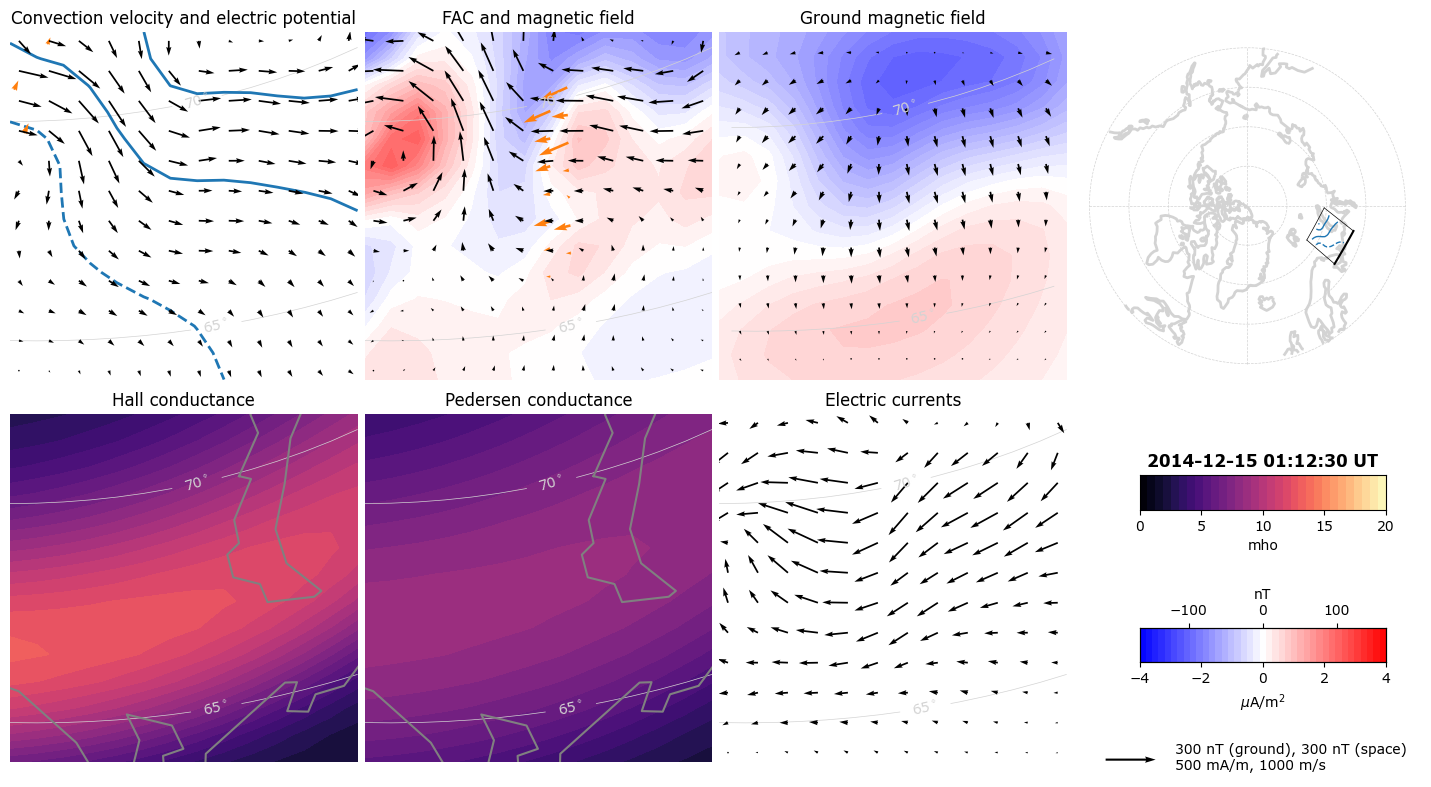

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


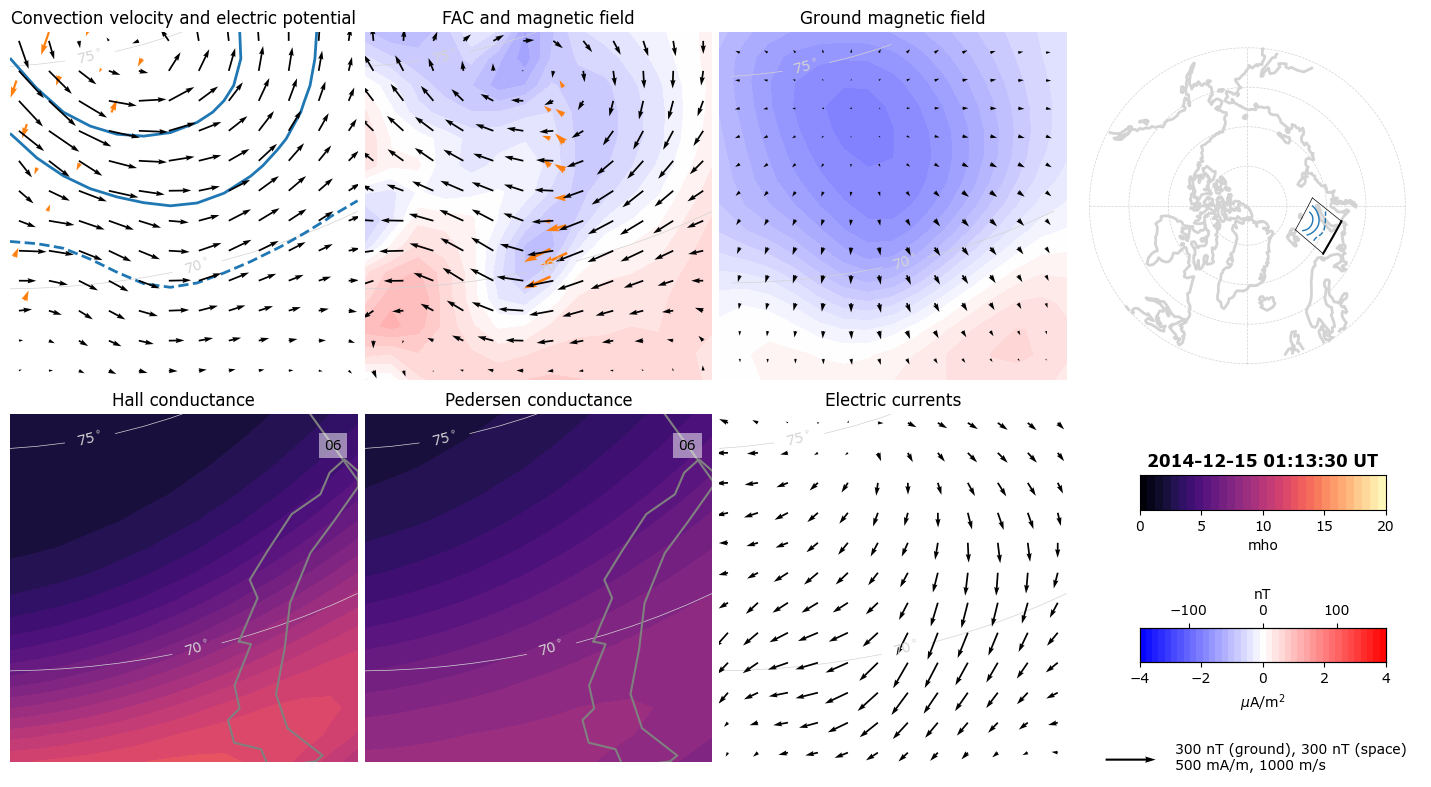

Lompe output figures for each time step saved in temporary folder: /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/tmp/
GIF saved in outputs directory: /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/lompe_l1-1_l2-1.gif


In [ ]:
# Regularization parameters for Lompe analysis
l1, l2 = 1, 1

lompe_models = run_lompe(center_times, time_step, grids, datasets, SHs, SPs, l1, l2)
lompe_frames = lompe_output(lompe_models, gif_speed)

In [14]:
lompe_models[0]['model'].data['convection'][0].values.shape

(67,)

In [ ]:
lompe_models[0]['model']

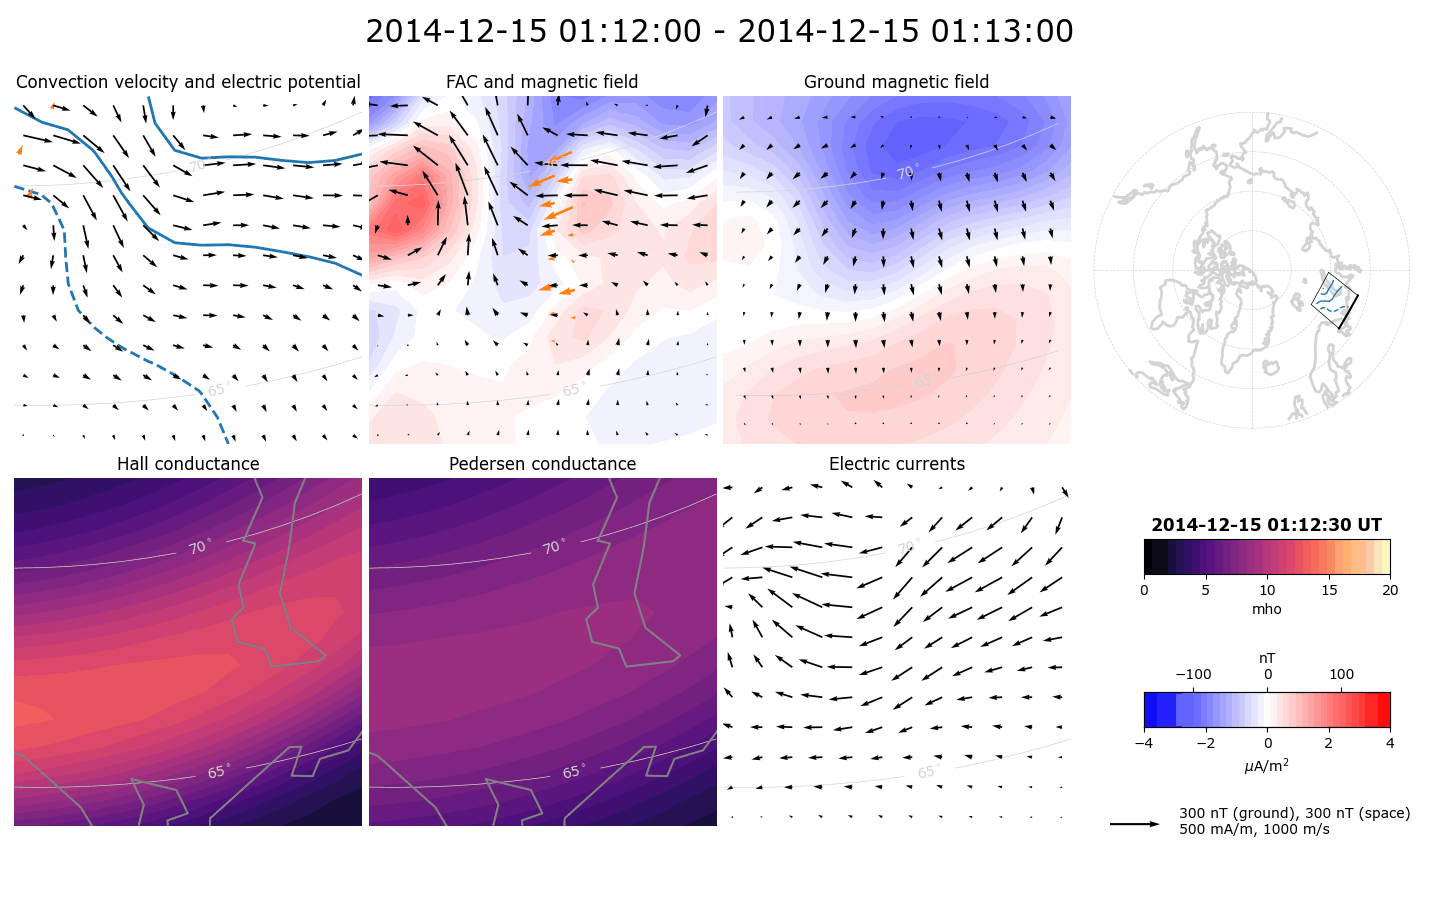

In [15]:
lompe_frames[0].save(
    "lompe.gif",
    save_all=True,
    append_images=lompe_frames[1:],
    duration=750,
    loop=0
)

from IPython.display import Image, display

display(Image(filename='lompe.gif')) #TODO compare with the gif saved in outputs

In [16]:
lompe_models[0]['model'].grid_E.lat
hemi = 'NORTH' if lompe_models[0]['model'].grid_E.lat.all() > 0 else 'SOUTH'
hemi


'NORTH'


 Running LompeOSSE validation...
do i need to load gamera data here?
Loading Gamera data/snapshot #0
time offset: 0 hours
2014-12-15 01:12:30

 Initializing synthetic model...

 Scanning user datasets and searching for corresponding Gamera data...
efield dataset not found
convection dataset found..
Getting Gamera convection data
Getting Gamera electric field
2026-02-17 22:45:05.336581
(67,)
2026-02-17 22:45:14.581488
Duration: 0:00:09.244907
..Gamera convection data extracted
ground_mag dataset found..
Getting Gamera magnetic field data
..Gamera ground_mag data extracted
space_mag_full dataset not found
space_mag_fac dataset found..
Getting Gamera magnetic field data
..Gamera space_mag_fac data extracted
space_mag_fac dataset found..
Getting Gamera magnetic field data
..Gamera space_mag_fac data extracted
fac dataset not found

 Clearing input model...
Adding Gamera datasets

 ...Synthetic model generated
space_mag_fac: Measurement uncertainty effectively changed from 3e-08 to 4.24264

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Duration: 0:00:04.351359


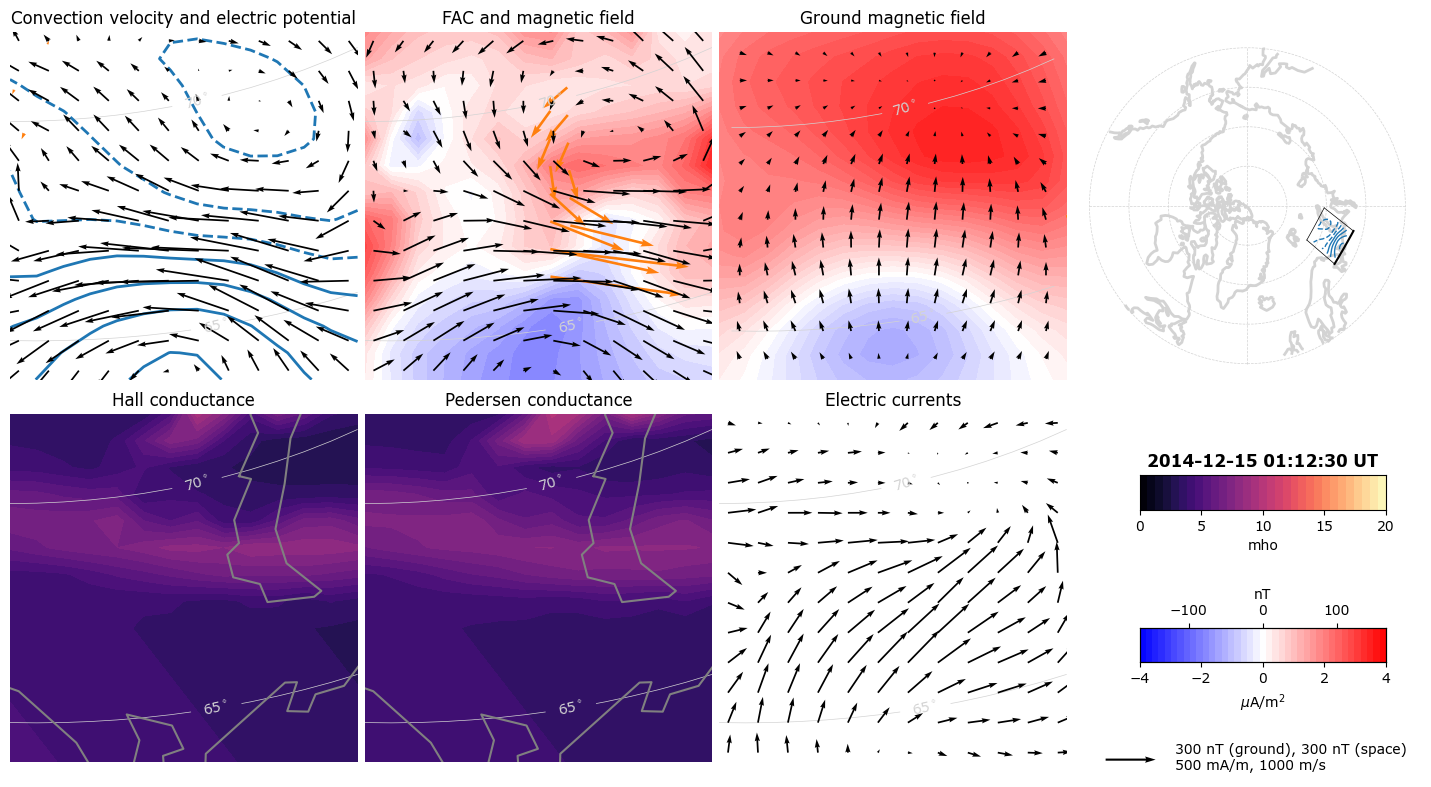

LompeOSSE analysis time: 2014-12-15 01:12:30 (2014-12-15 01:12:30 + time offset 0)
Getting Gamera Potential
2026-02-17 22:47:05.777316
Duration: 0:00:05.369718
Getting Gamera convection data
Getting Gamera electric field
2026-02-17 22:47:13.550871
(144,)
2026-02-17 22:47:22.775483
Duration: 0:00:09.224612
Getting Gamera Field-aligned current
2026-02-17 22:47:24.634067
Duration: 0:00:05.095822
Getting Gamera magnetic field data
Getting Gamera magnetic field data
Getting Gamera Pedersen conductance
2026-02-17 22:47:36.885593
Duration: 0:00:05.039979
Getting Gamera Hall conductance
2026-02-17 22:47:43.725978
Duration: 0:00:06.714096
Getting Gamera electric field
2026-02-17 22:47:52.881250
(144,)
2026-02-17 22:48:02.904967
Duration: 0:00:10.023717


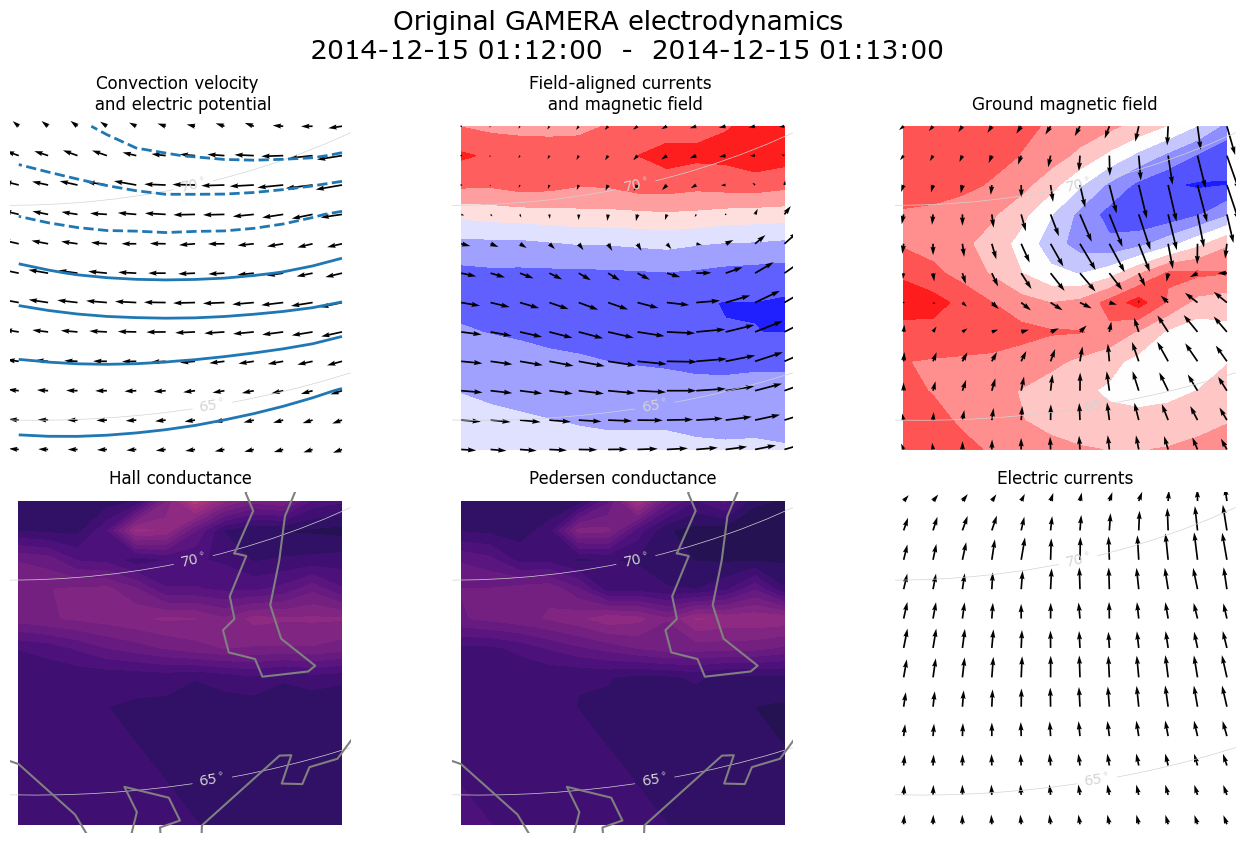

Getting Gamera Hall conductance
2026-02-17 22:48:05.880548
Duration: 0:00:06.174669
Getting Gamera Pedersen conductance
2026-02-17 22:48:13.844893
Duration: 0:00:04.540736
Getting Gamera Hall conductance
2026-02-17 22:48:20.178989
Duration: 0:00:04.443974
Getting Gamera Pedersen conductance
2026-02-17 22:48:26.410872
Duration: 0:00:05.242731
Getting Gamera Hall conductance
2026-02-17 22:48:33.459310
Duration: 0:00:05.852541
Getting Gamera Pedersen conductance
2026-02-17 22:48:41.105961
Duration: 0:00:04.773114
Getting Gamera Hall conductance
2026-02-17 22:48:47.694233
Duration: 0:00:04.511867
Getting Gamera Pedersen conductance
2026-02-17 22:48:54.014871
Duration: 0:00:05.815950
Getting Gamera Hall conductance
2026-02-17 22:49:01.646613
Duration: 0:00:04.193869
Getting Gamera Pedersen conductance
2026-02-17 22:49:07.707844
Duration: 0:00:05.835885
Getting Gamera Hall conductance
2026-02-17 22:49:15.417239
Duration: 0:00:03.951341
Getting Gamera Pedersen conductance
2026-02-17 22:49:21.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Duration: 0:00:04.729790


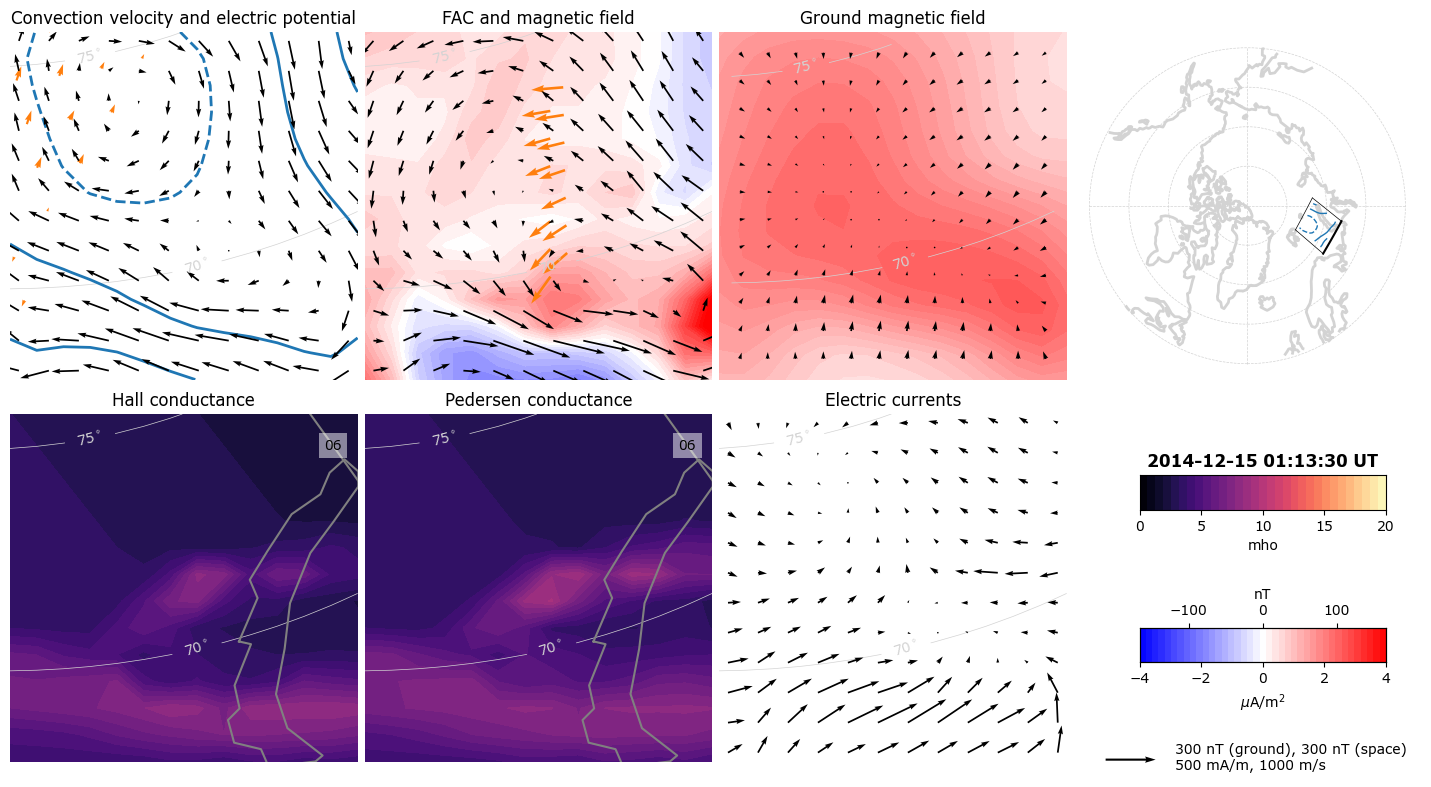

LompeOSSE analysis time: 2014-12-15 01:13:30 (2014-12-15 01:13:30 + time offset 0)
Getting Gamera Potential
2026-02-17 22:49:28.931844
Duration: 0:00:05.101072
Getting Gamera convection data
Getting Gamera electric field
2026-02-17 22:49:36.411328
(144,)
2026-02-17 22:49:46.890410
Duration: 0:00:10.479082
Getting Gamera Field-aligned current
2026-02-17 22:49:48.712330
Duration: 0:00:04.186155
Getting Gamera magnetic field data
Getting Gamera magnetic field data
Getting Gamera Pedersen conductance
2026-02-17 22:50:00.074208
Duration: 0:00:06.613505
Getting Gamera Hall conductance
2026-02-17 22:50:08.523849
Duration: 0:00:04.770091
Getting Gamera electric field
2026-02-17 22:50:15.666861
(144,)
2026-02-17 22:50:26.288101
Duration: 0:00:10.621240


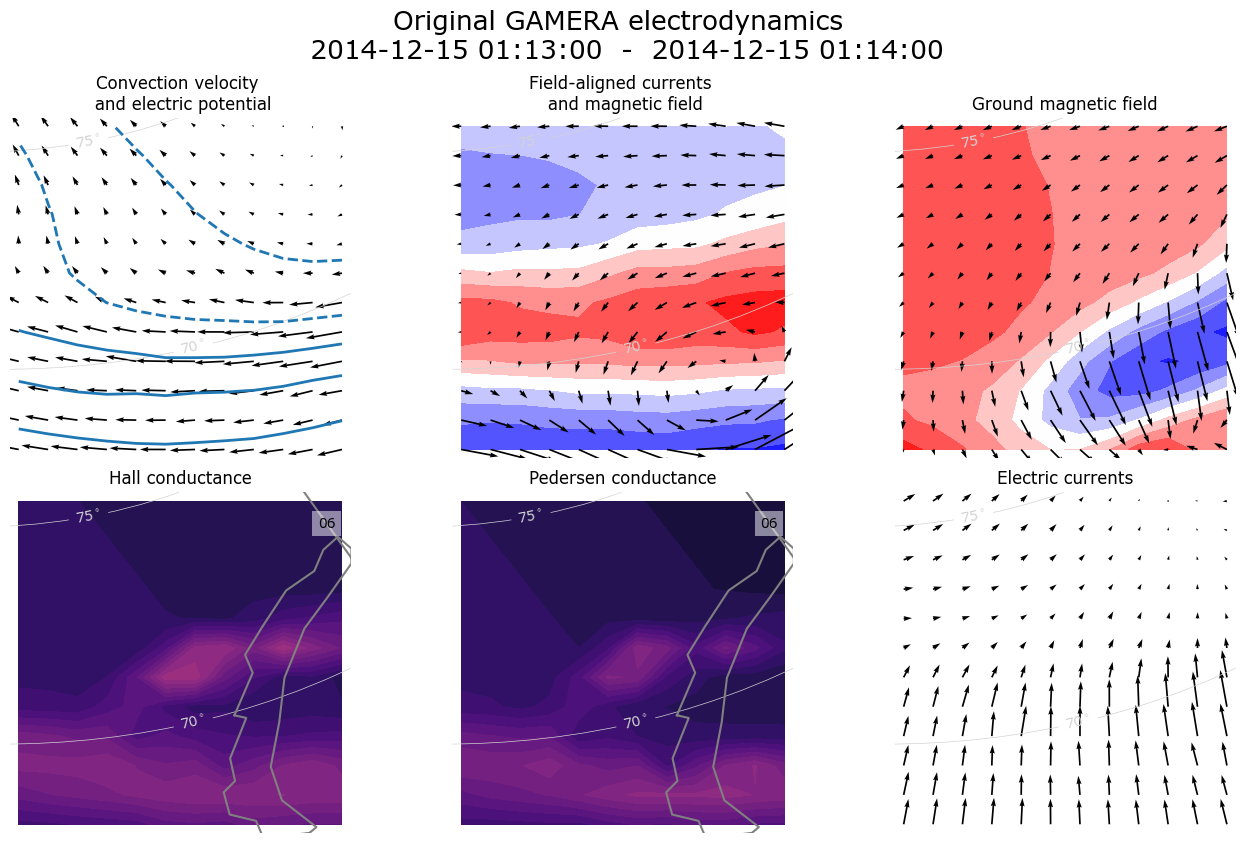

LompeOSSE output figures for each time step saved in temporary folder: /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/tmp/
GIF saved in outputs directory: /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/lompeOSSE_electrodynamics.gif and /Users/margot/Docs/Academia/Research/Python/SwarmDF/src/outputs/GAMERA_electrodynamics.gif


In [ ]:
lompeOSSE_models, gamera_models = run_lompeOSSE(lompe_models) #TODO add time offset and gamera snapshot
lompeOSSE_frames, gamera_frames_pil = lompeOSSE_output(lompeOSSE_models, gamera_models, gif_speed)


In [18]:
lompeOSSE_frames[0].save(
    "lompe.gif",
    save_all=True,
    append_images=lompeOSSE_frames[1:],
    duration=750,
    loop=0
)

from IPython.display import Image, display

display(Image(filename='lompeosse.gif')) #TODO compare with the gif saved in outputs

FileNotFoundError: [Errno 2] No such file or directory: 'lompeosse.gif'

In [ ]:
lompeOSSE_models[0]['osse_model'].time

AttributeError: 'Emodel' object has no attribute 'timestamp'

In [ ]:
gamera_models[0]['gamera_output'].time

Timestamp('2014-12-15 01:12:30', freq='60S')

In [ ]:
gamera_models[0]['gamera_output'].time